<a href="https://colab.research.google.com/github/Fofita911/Fisica-computacional/blob/main/Proyecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

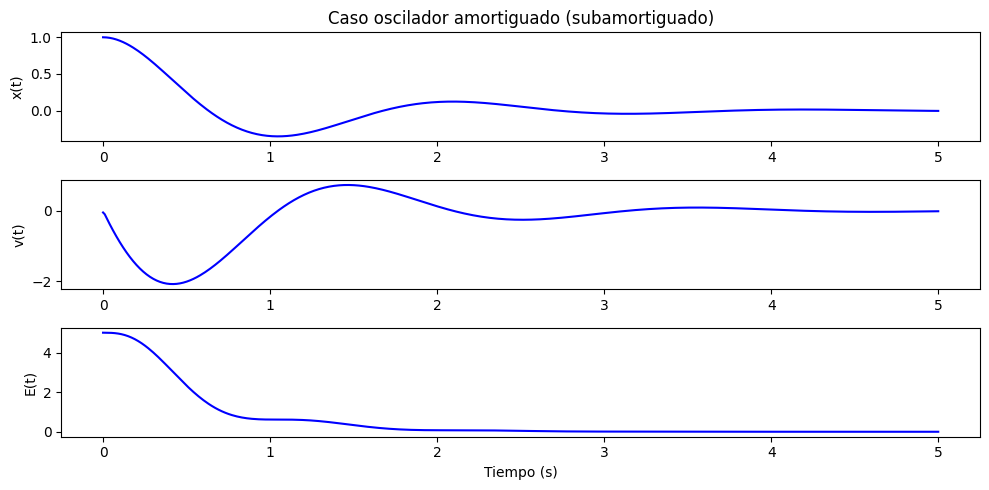

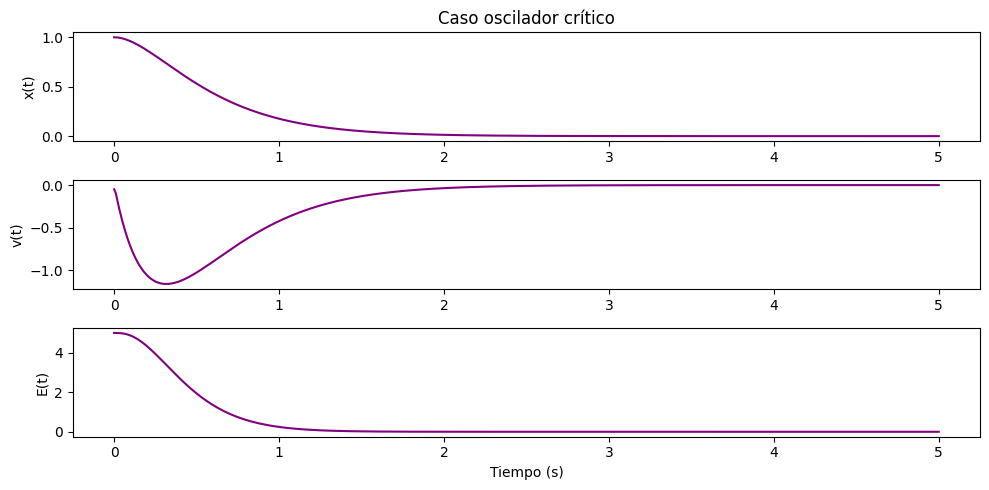

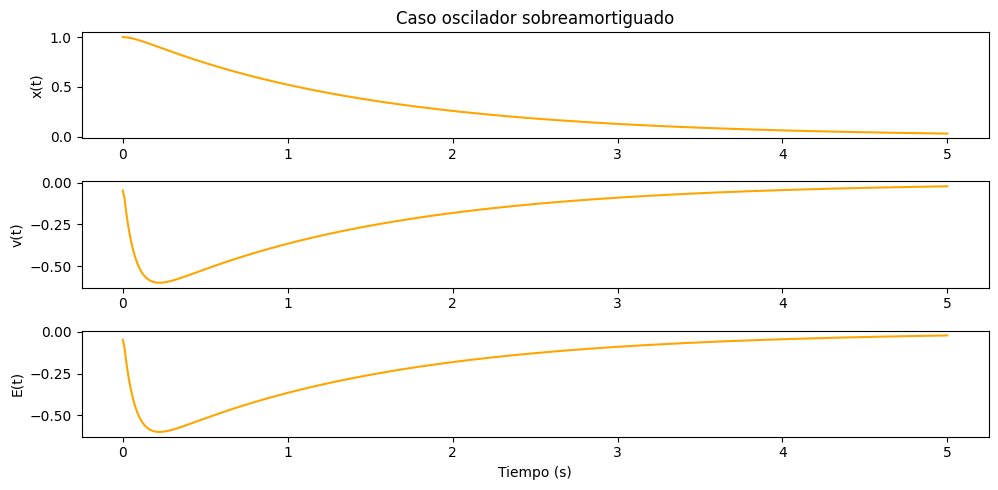

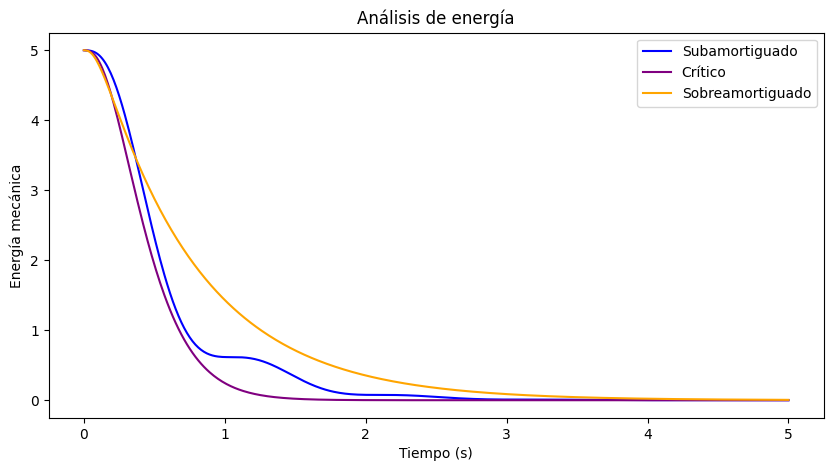

Energía en t=1,2,5 s (J):
t=1s -> Sub: 0.6165, Crítico: 0.2425, Sobre: 1.4278
t=2s -> Sub: 0.0767, Crítico: 0.0015, Sobre: 0.3516
t=5s -> Sub: 0.0002, Crítico: 0.0000, Sobre: 0.0053


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# datos
masa = 1.0
resorte = 10.0
x0 = 1.0
v0 = 0.0
tiempo = np.linspace(0,5,500)

# funcion para cada caso
def sub_amortiguado(m,k,b,x0,v0,t):
    w0 = np.sqrt(k/m)
    wd = np.sqrt(w0**2 - (b/(2*m))**2)
    A = x0
    B = (v0 + (b/(2*m))*x0)/wd
    x = np.exp(-b*t/(2*m))*(A*np.cos(wd*t)+B*np.sin(wd*t))
    v = np.gradient(x,t)
    E = 0.5*m*v**2 + 0.5*k*x**2
    return x,v,E

def critico(m,k,b,x0,v0,t):
    r = -b/(2*m)
    A = x0
    B = v0 - r*x0
    x = (A+B*t)*np.exp(r*t)
    v = np.gradient(x,t)
    E = 0.5*m*v**2 + 0.5*k*x**2
    return x,v,E

def sobre_amortiguado(m,k,b,x0,v0,t):
    r1 = (-b + np.sqrt(b**2-4*m*k))/(2*m)
    r2 = (-b - np.sqrt(b**2-4*m*k))/(2*m)
    A = (v0 - r2*x0)/(r1-r2)
    B = x0 - A
    x = A*np.exp(r1*t)+B*np.exp(r2*t)
    v = np.gradient(x,t)
    E = 0.5*m*v**2 + 0.5*k*x**2
    return x,v,E

# valores de b para cada caso
b_sub = 2.0
b_cri = 2*np.sqrt(m*k)
b_sob = 15.0

# simulaciones
x1,v1,E1 = sub_amortiguado(m,k,b_sub,x0,v0,t)
x2,v2,E2 = critico(m,k,b_cri,x0,v0,t)
x3,v3,E3 = sobre_amortiguado(m,k,b_sob,x0,v0,t)

# Graficas por casos
# Caso subamortiguado
plt.figure(figsize=(10,5))
plt.subplot(3,1,1); plt.plot(t,x1,color='blue'); plt.ylabel("x(t)"); plt.title("Caso oscilador amortiguado (subamortiguado)")
plt.subplot(3,1,2); plt.plot(t,v1,color='blue'); plt.ylabel("v(t)")
plt.subplot(3,1,3); plt.plot(t,E1,color='blue'); plt.ylabel("E(t)"); plt.xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

# Caso crítico
plt.figure(figsize=(10,5))
plt.subplot(3,1,1); plt.plot(t,x2,color='purple'); plt.ylabel("x(t)"); plt.title("Caso oscilador crítico")
plt.subplot(3,1,2); plt.plot(t,v2,color='purple'); plt.ylabel("v(t)")
plt.subplot(3,1,3); plt.plot(t,E2,color='purple'); plt.ylabel("E(t)"); plt.xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

# Caso sobreamortiguado
plt.figure(figsize=(10,5))
plt.subplot(3,1,1); plt.plot(t,x3,color='orange'); plt.ylabel("x(t)"); plt.title("Caso oscilador sobreamortiguado")
plt.subplot(3,1,2); plt.plot(t,v3,color='orange'); plt.ylabel("v(t)")
plt.subplot(3,1,3); plt.plot(t,v3,color='orange'); plt.ylabel("E(t)"); plt.xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

# Analisis de energia comparado
plt.figure(figsize=(10,5))
plt.plot(t,E1,label="Subamortiguado",color='blue')
plt.plot(t,E2,label="Crítico",color='purple')
plt.plot(t,E3,label="Sobreamortiguado",color='orange')
plt.title("Análisis de energía")
plt.xlabel("Tiempo (s)")
plt.ylabel("Energía mecánica")
plt.legend()
plt.show()

# energia en tiempos específicos
tiempos = [1,2,5]
print("Energía en t=1,2,5 s (J):")
for tf in tiempos:
    i = np.argmin(np.abs(t-tf))
    print(f"t={tf}s -> Sub: {E1[i]:.4f}, Crítico: {E2[i]:.4f}, Sobre: {E3[i]:.4f}")